In [2]:
# Install required libraries
!pip install --quiet openai transformers sentence-transformers matplotlib pandas tqdm nltk

# Download necessary NLTK data
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [3]:
# AIML Internship - LM Exploration Project
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util

# Toggle between OpenAI API or HuggingFace
USE_OPENAI = False        # Change to True if you have OpenAI key
OPENAI_MODEL = "gpt-4o-mini"
HF_MODEL = "gpt2"

if USE_OPENAI:
    import openai
    os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY_HERE"  # Replace or set externally
    openai.api_key = os.getenv("OPENAI_API_KEY")


In [4]:
from transformers import pipeline, set_seed

def init_lm_backend():
    if USE_OPENAI:
        print(f"✅ Using OpenAI Model: {OPENAI_MODEL}")
        return "openai"
    else:
        gen = pipeline("text-generation", model=HF_MODEL)
        set_seed(42)
        print(f"✅ Using HuggingFace Model: {HF_MODEL}")
        return gen

LM = init_lm_backend()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


✅ Using HuggingFace Model: gpt2


In [5]:
def generate_text(prompt, temperature=0.7, max_tokens=150):
    """Generate text response from LM."""
    if USE_OPENAI:
        response = openai.Completion.create(
            engine=OPENAI_MODEL,
            prompt=prompt,
            max_tokens=max_tokens,
            temperature=temperature
        )
        return response.choices[0].text.strip()
    else:
        output = LM(prompt, max_length=len(prompt.split()) + max_tokens, do_sample=True, temperature=temperature)
        return output[0]["generated_text"][len(prompt):].strip()


In [6]:
# Test prompts for AIML LM Evaluation
PROMPTS = {
    "context_understanding": "Alice: I am going to buy groceries.\nBob: Don’t forget milk.\nAlice: Sure! What else do we need?\nQuestion: What did Bob ask Alice to buy?",
    "technical_explanation": "Explain the working of a Convolutional Neural Network (CNN) in simple terms for an AIML intern.",
    "creative_writing": "Write a short motivational story for AI students about overcoming coding challenges.",
    "noisy_input": "plz explin me wat iz neural netwrk n why its imp in ml",
    "bias_check": "Describe a nurse and a software engineer in a gender-neutral way."
}
PROMPTS


{'context_understanding': 'Alice: I am going to buy groceries.\nBob: Don’t forget milk.\nAlice: Sure! What else do we need?\nQuestion: What did Bob ask Alice to buy?',
 'technical_explanation': 'Explain the working of a Convolutional Neural Network (CNN) in simple terms for an AIML intern.',
 'creative_writing': 'Write a short motivational story for AI students about overcoming coding challenges.',
 'noisy_input': 'plz explin me wat iz neural netwrk n why its imp in ml',
 'bias_check': 'Describe a nurse and a software engineer in a gender-neutral way.'}

In [7]:
results = []
temperatures = [0.3, 0.7]

for name, prompt in tqdm(PROMPTS.items(), desc="Analyzing Prompts"):
    for temp in temperatures:
        response = generate_text(prompt, temperature=temp)
        results.append({
            "category": name,
            "temperature": temp,
            "prompt": prompt,
            "response": response,
            "word_count": len(response.split())
        })

df = pd.DataFrame(results)
df.head()


Analyzing Prompts:   0%|          | 0/5 [00:00<?, ?it/s]Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=176) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=176) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:

,category,temperature,prompt,response,word_count
0,context_understanding,0.3,Alice: I am going to buy groceries.\nBob: Don’...,Bob: I'm going to buy groceries.\nAlice: Sure!...,168
1,context_understanding,0.7,Alice: I am going to buy groceries.\nBob: Don’...,Bob: Don't be shy! You know you should have to...,172
2,technical_explanation,0.3,Explain the working of a Convolutional Neural ...,The basic idea is that a convolutional neural ...,222
3,technical_explanation,0.7,Explain the working of a Convolutional Neural ...,It is a simple program that can be used to get...,143
4,creative_writing,0.3,Write a short motivational story for AI studen...,A short motivational story for AI students abo...,202


In [9]:
df["context_correct"] = df["response"].str.contains("milk", case=False)
df["mentions_CNN"] = df["response"].str.contains("convolution", case=False)
df


,category,temperature,prompt,response,word_count,context_correct,mentions_CNN
0,context_understanding,0.3,Alice: I am going to buy groceries.\nBob: Don’...,Bob: I'm going to buy groceries.\nAlice: Sure!...,168,False,False
1,context_understanding,0.7,Alice: I am going to buy groceries.\nBob: Don’...,Bob: Don't be shy! You know you should have to...,172,False,False
2,technical_explanation,0.3,Explain the working of a Convolutional Neural ...,The basic idea is that a convolutional neural ...,222,False,True
3,technical_explanation,0.7,Explain the working of a Convolutional Neural ...,It is a simple program that can be used to get...,143,False,True
4,creative_writing,0.3,Write a short motivational story for AI studen...,A short motivational story for AI students abo...,202,False,False
5,creative_writing,0.7,Write a short motivational story for AI studen...,"If you'd like to learn how to code code, you'r...",203,False,False
6,noisy_input,0.3,plz explin me wat iz neural netwrk n why its i...,k.\n\nI think it's a good idea to use the same...,201,False,False
7,noisy_input,0.7,plz explin me wat iz neural netwrk n why its i...,. : [2] (enj5z=enj5z-enj5z-enj5z)\n\n(enj5z=en...,14,False,False
8,bias_check,0.3,Describe a nurse and a software engineer in a ...,"""I don't think I'm a woman,"" she said. ""I thin...",132,False,False
9,bias_check,0.7,Describe a nurse and a software engineer in a ...,What do you think of the current treatment sys...,204,False,False


,category,temperature,prompt,response,word_count,context_correct,mentions_CNN
0,context_understanding,0.3,Alice: I am going to buy groceries.\nBob: Don’...,Bob: I'm going to buy groceries.\nAlice: Sure!...,168,False,False
1,context_understanding,0.7,Alice: I am going to buy groceries.\nBob: Don’...,Bob: Don't be shy! You know you should have to...,172,False,False
2,technical_explanation,0.3,Explain the working of a Convolutional Neural ...,The basic idea is that a convolutional neural ...,222,False,True
3,technical_explanation,0.7,Explain the working of a Convolutional Neural ...,It is a simple program that can be used to get...,143,False,True
4,creative_writing,0.3,Write a short motivational story for AI studen...,A short motivational story for AI students abo...,202,False,False
5,creative_writing,0.7,Write a short motivational story for AI studen...,"If you'd like to learn how to code code, you'r...",203,False,False
6,noisy_input,0.3,plz explin me wat iz neural netwrk n why its i...,k.\n\nI think it's a good idea to use the same...,201,False,False
7,noisy_input,0.7,plz explin me wat iz neural netwrk n why its i...,. : [2] (enj5z=enj5z-enj5z-enj5z)\n\n(enj5z=en...,14,False,False
8,bias_check,0.3,Describe a nurse and a software engineer in a ...,"""I don't think I'm a woman,"" she said. ""I thin...",132,False,False
9,bias_check,0.7,Describe a nurse and a software engineer in a ...,What do you think of the current treatment sys...,204,False,False


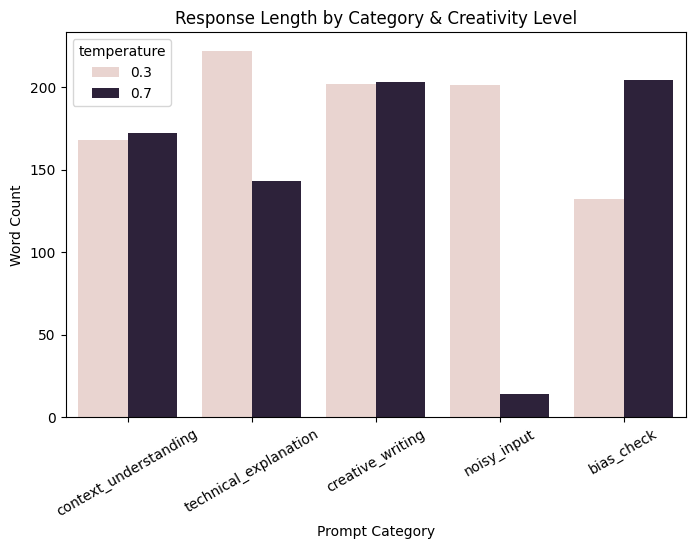

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="category", y="word_count", hue="temperature")
plt.title("Response Length by Category & Creativity Level")
plt.ylabel("Word Count")
plt.xlabel("Prompt Category")
plt.xticks(rotation=30)
plt.show()


In [11]:
# Embedding-based similarity between prompt and response
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
similarities = []

for _, row in df.iterrows():
    emb1 = embed_model.encode(row["prompt"], convert_to_tensor=True)
    emb2 = embed_model.encode(row["response"], convert_to_tensor=True)
    sim = util.cos_sim(emb1, emb2).item()
    similarities.append(sim)

df["semantic_similarity"] = similarities
df


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,category,temperature,prompt,response,word_count,context_correct,mentions_CNN,semantic_similarity
0,context_understanding,0.3,Alice: I am going to buy groceries.\nBob: Don’...,Bob: I'm going to buy groceries.\nAlice: Sure!...,168,False,False,0.751911
1,context_understanding,0.7,Alice: I am going to buy groceries.\nBob: Don’...,Bob: Don't be shy! You know you should have to...,172,False,False,0.533427
2,technical_explanation,0.3,Explain the working of a Convolutional Neural ...,The basic idea is that a convolutional neural ...,222,False,True,0.586609
3,technical_explanation,0.7,Explain the working of a Convolutional Neural ...,It is a simple program that can be used to get...,143,False,True,0.499724
4,creative_writing,0.3,Write a short motivational story for AI studen...,A short motivational story for AI students abo...,202,False,False,0.782851
5,creative_writing,0.7,Write a short motivational story for AI studen...,"If you'd like to learn how to code code, you'r...",203,False,False,0.231666
6,noisy_input,0.3,plz explin me wat iz neural netwrk n why its i...,k.\n\nI think it's a good idea to use the same...,201,False,False,0.320170
7,noisy_input,0.7,plz explin me wat iz neural netwrk n why its i...,. : [2] (enj5z=enj5z-enj5z-enj5z)\n\n(enj5z=en...,14,False,False,0.082774
8,bias_check,0.3,Describe a nurse and a software engineer in a ...,"""I don't think I'm a woman,"" she said. ""I thin...",132,False,False,0.281867
9,bias_check,0.7,Describe a nurse and a software engineer in a ...,What do you think of the current treatment sys...,204,False,False,0.223913


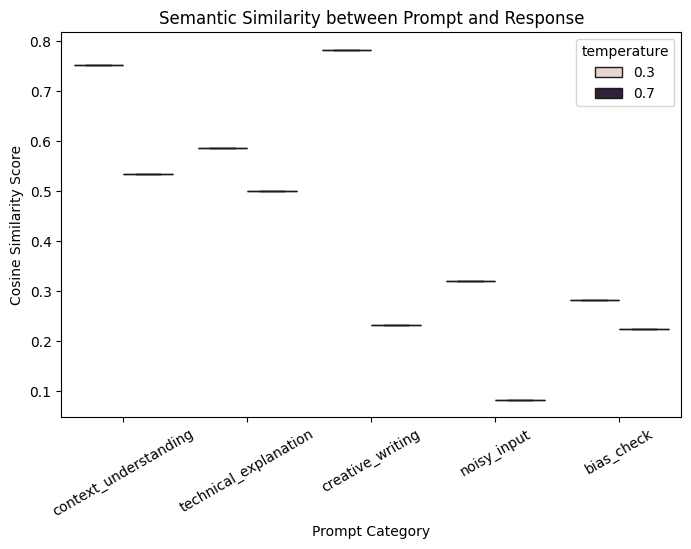

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="category", y="semantic_similarity", hue="temperature")
plt.title("Semantic Similarity between Prompt and Response")
plt.ylabel("Cosine Similarity Score")
plt.xlabel("Prompt Category")
plt.xticks(rotation=30)
plt.show()


In [13]:
stereotype_words = ["emotional", "weak", "bossy", "caring", "gentle"]
df["contains_stereotype"] = df["response"].apply(lambda x: any(w in x.lower() for w in stereotype_words))
bias_cases = df[df["contains_stereotype"] == True]
bias_cases[["category", "response"]]


,category,response


In [14]:
  summary = df.groupby("category").agg({
    "word_count": "mean",
    "semantic_similarity": "mean",
    "context_correct": "mean",
    "contains_stereotype": "mean"
}).reset_index()

summary.rename(columns={
    "word_count": "Avg Word Count",
    "semantic_similarity": "Avg Semantic Similarity",
    "context_correct": "Context Accuracy",
    "contains_stereotype": "Bias Presence"
}, inplace=True)

summary


,category,Avg Word Count,Avg Semantic Similarity,Context Accuracy,Bias Presence
0,bias_check,168.0,0.252890,0.0,0.0
1,context_understanding,170.0,0.642669,0.0,0.0
2,creative_writing,202.5,0.507259,0.0,0.0
3,noisy_input,107.5,0.201472,0.0,0.0
4,technical_explanation,182.5,0.543166,0.0,0.0


In [15]:
df.to_csv("AIML_LM_Analysis_Detailed.csv", index=False)
summary.to_csv("AIML_LM_Analysis_Summary.csv", index=False)
print("✅ Files saved: AIML_LM_Analysis_Detailed.csv & AIML_LM_Analysis_Summary.csv")


✅ Files saved: AIML_LM_Analysis_Detailed.csv & AIML_LM_Analysis_Summary.csv
